In [ ]:
import os
import sqlite3
import sys
import traceback
import csv

db_path = os.path.join('.', 'data', 'nyc_air_health.db')
os.makedirs(os.path.dirname(db_path), exist_ok=True)

print('Creating/opening database at', db_path)
conn = sqlite3.connect(db_path)

try:
    import pandas as pd
    print('Using pandas to import CSVs (fast).')
    aq_path = os.path.join('.', 'data', 'raw', 'air_quality.csv')
    if os.path.exists(aq_path):
        print('Loading', aq_path)
        for chunk in pd.read_csv(aq_path, chunksize=200000):
            chunk.to_sql('air_quality', conn, if_exists='append', index=False)
        print('Imported air_quality')
    else:
        print('air_quality.csv not found at', aq_path)

    ben_path = os.path.join('.', 'data', 'raw', 'NYNY_BenMAP.csv')
    if os.path.exists(ben_path):
        print('Loading', ben_path)
        for chunk in pd.read_csv(ben_path, chunksize=200000):
            chunk.to_sql('benmap', conn, if_exists='append', index=False)
        print('Imported benmap')
    else:
        print('NYNY_BenMAP.csv not found at', ben_path)

except Exception:
    print('pandas import failed or not available, falling back to CSV reader')
    try:
        cur = conn.cursor()
        cur.execute('''
        CREATE TABLE IF NOT EXISTS air_quality (
          unique_id INTEGER,
          indicator_id INTEGER,
          name TEXT,
          measure TEXT,
          measure_info TEXT,
          geo_type_name TEXT,
          geo_join_id TEXT,
          geo_place_name TEXT,
          time_period TEXT,
          start_date TEXT,
          data_value REAL,
          message TEXT
        )
        ''')
        conn.commit()

        aq_path = os.path.join('.', 'data', 'raw', 'air_quality.csv')
        if os.path.exists(aq_path):
            with open(aq_path, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                header = next(reader)
                ins_q = 'INSERT INTO air_quality VALUES (%s)' % ','.join(['?'] * len(header))
                batch = []
                for i, row in enumerate(reader, 1):
                    batch.append(row)
                    if i % 10000 == 0:
                        cur.executemany(ins_q, batch)
                        conn.commit()
                        batch = []
                if batch:
                    cur.executemany(ins_q, batch)
                    conn.commit()
            print('Imported air_quality via csv reader')

        ben_path = os.path.join('.', 'data', 'raw', 'NYNY_BenMAP.csv')
        if os.path.exists(ben_path):
            with open(ben_path, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                header = next(reader)
                cols = [f'"{c}" TEXT' for c in header]
                cur.execute('DROP TABLE IF EXISTS benmap')
                cur.execute('CREATE TABLE benmap (' + ','.join(cols) + ')')
                conn.commit()
                ins_q = 'INSERT INTO benmap VALUES (%s)' % ','.join(['?'] * len(header))
                batch = []
                for i, row in enumerate(reader, 1):
                    batch.append(row)
                    if i % 5000 == 0:
                        cur.executemany(ins_q, batch)
                        conn.commit()
                        batch = []
                if batch:
                    cur.executemany(ins_q, batch)
                    conn.commit()
            print('Imported benmap via csv reader')

    except Exception:
        print('Fallback import failed')
        print(traceback.format_exc())

conn.close()
print('Done.')

Creating/opening database at .\data\nyc_air_health.db
Using pandas to import CSVs (fast).
Loading .\data\raw\air_quality.csv
Imported air_quality
Loading .\data\raw\NYNY_BenMAP.csv
Imported benmap
Done.


In [ ]:
import os
import sys
import csv
import traceback

out_lines = []

files = [r".\data\raw\NYNY_BenMAP.csv", r".\data\raw\air_quality.csv"]
for fn in files:
    out_lines.append(f"File: {fn}")
    if not os.path.exists(fn):
        out_lines.append("  MISSING")
        out_lines.append("-")
        continue
    try:
        with open(fn, newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader)
            out_lines.append(f"  Columns: {len(header)}")
            out_lines.append("  First 20 column names: " + ", ".join(header[:20]))
            sample = []
            for i, row in enumerate(reader):
                if i >= 4:
                    break
                sample.append(row)
        out_lines.append("  Sample rows (up to 5):")
        for r in sample:
            out_lines.append("    " + ", ".join(r[:10]) + ("..." if len(r) > 10 else ""))

        count = 0
        with open(fn, 'rb') as f:
            for chunk in f:
                count += chunk.count(b'\n')
        out_lines.append(f"  Approx rows (including header): {count}")

    except Exception:
        out_lines.append("  ERROR reading file")
        out_lines.append(traceback.format_exc())
    out_lines.append("-")

rep_dir = os.path.join('.', 'docs')
os.makedirs(rep_dir, exist_ok=True)
rep_path = os.path.join(rep_dir, 'inspect_report.txt')
with open(rep_path, 'w', encoding='utf-8') as out:
    out.write('\n'.join(out_lines))

print(f"Wrote inspection report to {rep_path}")

Wrote inspection report to .\docs\inspect_report.txt


In [ ]:
import os
import csv
import re
from datetime import datetime

raw_dir = os.path.join('.', 'data', 'raw')
out_dir = os.path.join('.', 'data', 'processed')
os.makedirs(out_dir, exist_ok=True)

print('Starting basic cleaning: time normalization and negative PM2.5 check')

aq_in = os.path.join(raw_dir, 'air_quality.csv')
aq_out = os.path.join(out_dir, 'air_quality_clean.csv')
if os.path.exists(aq_in):
    with open(aq_in, newline='', encoding='utf-8') as inf, open(aq_out, 'w', newline='', encoding='utf-8') as outf:
        reader = csv.DictReader(inf)
        fieldnames = list(reader.fieldnames) + ['year']
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()
        for row in reader:
            tp = row.get('Time Period', '') or row.get('time_period', '')
            year = ''
            m = re.search(r'(20\d{2})', tp)
            if m:
                year = m.group(1)
            else:
                sd = row.get('Start_Date', '') or row.get('start_date', '')
                try:
                    year = datetime.strptime(sd, '%m/%d/%Y').year if sd else ''
                except Exception:
                    try:
                        year = datetime.strptime(sd, '%Y-%m-%d').year if sd else ''
                    except Exception:
                        year = ''
            row['year'] = year
            writer.writerow(row)
    print('Wrote', aq_out)
else:
    print('air_quality.csv not found, skipping')

ben_in = os.path.join(raw_dir, 'NYNY_BenMAP.csv')
ben_out = os.path.join(out_dir, 'NYNY_BenMAP_clean.csv')
if os.path.exists(ben_in):
    with open(ben_in, newline='', encoding='utf-8') as inf, open(ben_out, 'w', newline='', encoding='utf-8') as outf:
        reader = csv.DictReader(inf)
        fieldnames = reader.fieldnames + ['pm25_negative_flag']
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()
        pm25_cols = [c for c in reader.fieldnames if 'PM25' in c or 'PM2.5' in c]
        for row in reader:
            neg_found = 0
            for c in pm25_cols:
                try:
                    v = float(row.get(c, '') or 0)
                    if v < 0:
                        neg_found += 1
                except Exception:
                    continue
            row['pm25_negative_flag'] = str(neg_found)
            writer.writerow(row)
    print('Wrote', ben_out, '(pm25 negative counts added)')
else:
    print('NYNY_BenMAP.csv not found, skipping')

print('Cleaning completed (basic). Review files in data/processed.')

Starting basic cleaning: time normalization and negative PM2.5 check
Wrote .\data\processed\air_quality_clean.csv
Wrote .\data\processed\NYNY_BenMAP_clean.csv (pm25 negative counts added)
Cleaning completed (basic). Review files in data/processed.


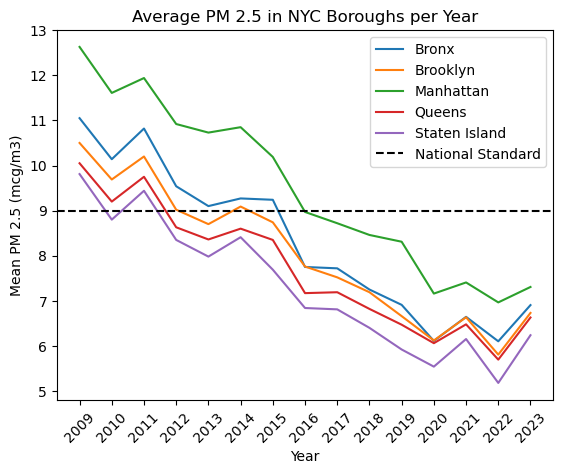

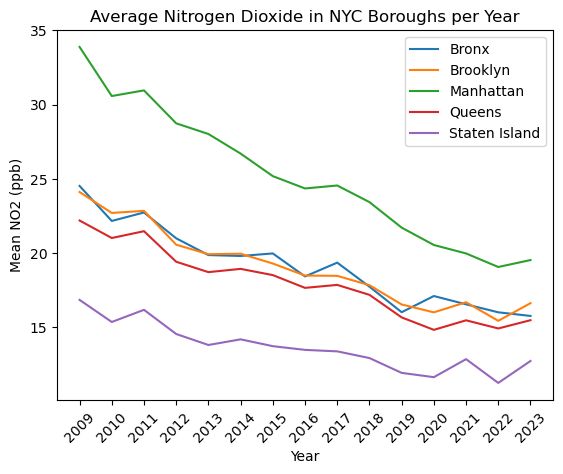

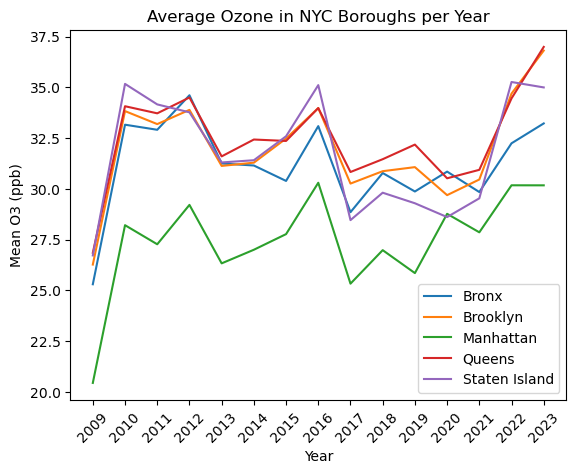

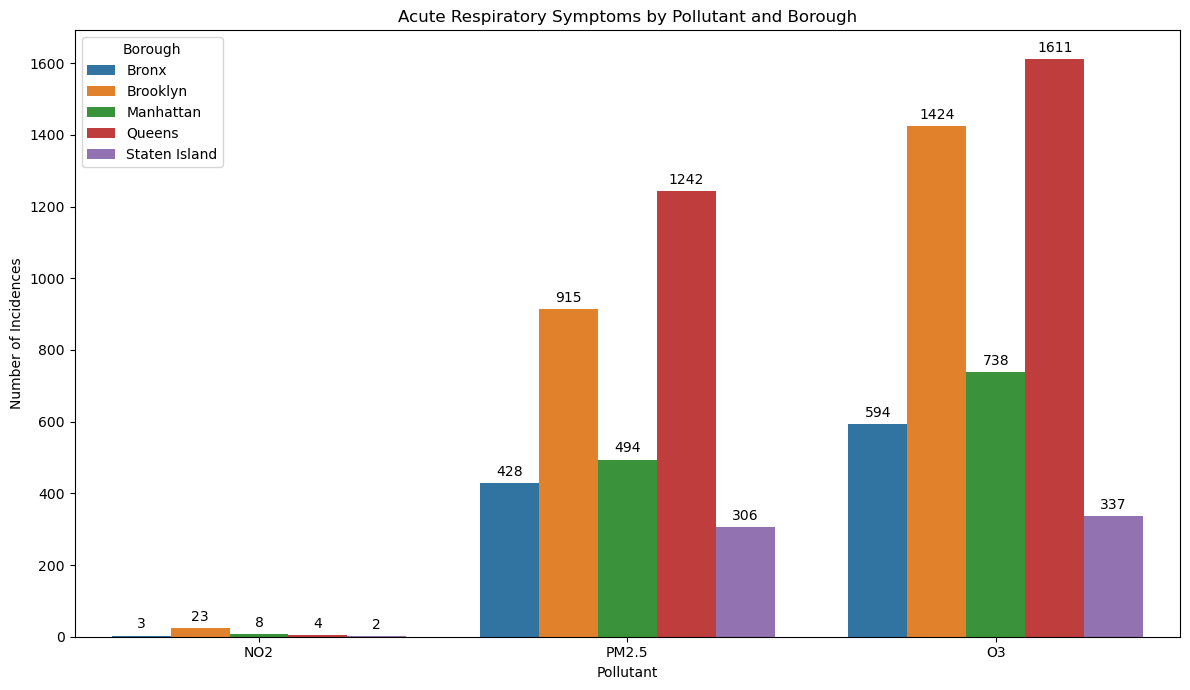

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

aq_clean_path=os.path.join('data', 'processed', 'air_quality_clean.csv')
df_air=pd.read_csv(os.path.abspath(aq_clean_path))

df_air_bronx=df_air[df_air['Geo Place Name']=='Bronx']
df_air_brooklyn=df_air[df_air['Geo Place Name'] == 'Brooklyn']
df_air_manhattan=df_air[df_air['Geo Place Name']=='Manhattan']
df_air_queens=df_air[df_air['Geo Place Name']=='Queens']
df_air_staten=df_air[df_air['Geo Place Name']=='Staten Island']

df_air_bronx_pm=df_air_bronx[(df_air_bronx['Name']=='Fine particles (PM 2.5)')&(df_air_bronx['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_brooklyn_pm=df_air_brooklyn[(df_air_brooklyn['Name']=='Fine particles (PM 2.5)')&(df_air_brooklyn['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_manhattan_pm=df_air_manhattan[(df_air_manhattan['Name']=='Fine particles (PM 2.5)')&(df_air_manhattan['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_queens_pm=df_air_queens[(df_air_queens['Name']=='Fine particles (PM 2.5)')&(df_air_queens['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_staten_pm=df_air_staten[(df_air_staten['Name']=='Fine particles (PM 2.5)')&(df_air_staten['Time Period'].str.contains('Annual Average'))].sort_values(by='year')

plt.plot(df_air_bronx_pm['year'], df_air_bronx_pm['Data Value'])
plt.plot(df_air_brooklyn_pm['year'], df_air_brooklyn_pm['Data Value'])
plt.plot(df_air_manhattan_pm['year'], df_air_manhattan_pm['Data Value'])
plt.plot(df_air_queens_pm['year'], df_air_queens_pm['Data Value'])
plt.plot(df_air_staten_pm['year'], df_air_staten_pm['Data Value'])
plt.axhline(y=9, color='black', linestyle='--')
plt.legend(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'National Standard'])
plt.locator_params(axis='x', nbins=16)
plt.xticks(rotation=45)
plt.title("Average PM 2.5 in NYC Boroughs per Year")
plt.xlabel('Year')
plt.ylabel('Mean PM 2.5 (mcg/m3)')
plt.savefig('pm25.png')
plt.show()

df_air_bronx_no2=df_air_bronx[(df_air_bronx['Name']=='Nitrogen dioxide (NO2)')&(df_air_bronx['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_brooklyn_no2=df_air_brooklyn[(df_air_brooklyn['Name']=='Nitrogen dioxide (NO2)')&(df_air_brooklyn['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_manhattan_no2=df_air_manhattan[(df_air_manhattan['Name']=='Nitrogen dioxide (NO2)')&(df_air_manhattan['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_queens_no2=df_air_queens[(df_air_queens['Name']=='Nitrogen dioxide (NO2)')&(df_air_queens['Time Period'].str.contains('Annual Average'))].sort_values(by='year')
df_air_staten_no2=df_air_staten[(df_air_staten['Name']=='Nitrogen dioxide (NO2)')&(df_air_staten['Time Period'].str.contains('Annual Average'))].sort_values(by='year')

plt.plot(df_air_bronx_no2['year'], df_air_bronx_no2['Data Value'])
plt.plot(df_air_brooklyn_no2['year'], df_air_brooklyn_no2['Data Value'])
plt.plot(df_air_manhattan_no2['year'], df_air_manhattan_no2['Data Value'])
plt.plot(df_air_queens_no2['year'], df_air_queens_no2['Data Value'])
plt.plot(df_air_staten_no2['year'], df_air_staten_no2['Data Value'])
plt.legend(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'National Standard'])
plt.locator_params(axis='x', nbins=16)
plt.xticks(rotation=45)
plt.title("Average Nitrogen Dioxide in NYC Boroughs per Year")
plt.xlabel('Year')
plt.ylabel('Mean NO2 (ppb)')
plt.savefig('no2.png')
plt.show()

df_air_bronx_o3=df_air_bronx[(df_air_bronx['Name']=='Ozone (O3)')&(df_air_bronx['Time Period'])].sort_values(by='year')
df_air_brooklyn_o3=df_air_brooklyn[(df_air_brooklyn['Name']=='Ozone (O3)')&(df_air_brooklyn['Time Period'])].sort_values(by='year')
df_air_manhattan_o3=df_air_manhattan[(df_air_manhattan['Name']=='Ozone (O3)')&(df_air_manhattan['Time Period'])].sort_values(by='year')
df_air_queens_o3=df_air_queens[(df_air_queens['Name']=='Ozone (O3)')&(df_air_queens['Time Period'])].sort_values(by='year')
df_air_staten_o3=df_air_staten[(df_air_staten['Name']=='Ozone (O3)')&(df_air_staten['Time Period'])].sort_values(by='year')

plt.plot(df_air_bronx_o3['year'], df_air_bronx_o3['Data Value'])
plt.plot(df_air_brooklyn_o3['year'], df_air_brooklyn_o3['Data Value'])
plt.plot(df_air_manhattan_o3['year'], df_air_manhattan_o3['Data Value'])
plt.plot(df_air_queens_o3['year'], df_air_queens_o3['Data Value'])
plt.plot(df_air_staten_o3['year'], df_air_staten_o3['Data Value'])
plt.legend(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'National Standard'])
plt.locator_params(axis='x', nbins=16)
plt.xticks(rotation=45)
plt.title("Average Ozone in NYC Boroughs per Year")
plt.xlabel('Year')
plt.ylabel('Mean O3 (ppb)')
plt.savefig('ozone.png')
plt.show()

ben_clean_path=os.path.join('data', 'processed', 'NYNY_BenMAP_clean.csv')
df_ben=pd.read_csv(os.path.abspath(ben_clean_path))

df_ben_a=df_ben[['bgrp', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']]

def get_borough_from_bgrp(bgrp):
    if 360050000000 <= bgrp <= 360059999999:
        return 'Bronx'
    elif 360470000000 <= bgrp <= 360479999999:
        return 'Brooklyn'
    elif 360610000000 <= bgrp <= 360619999999:
        return 'Manhattan'
    elif 360810000000 <= bgrp <= 360819999999:
        return 'Queens'
    elif 360850000000 <= bgrp <= 360859999999:
        return 'Staten Island'

df_ben_b=df_ben_a.copy()
df_ben_b['Borough'] = df_ben_b['bgrp'].apply(get_borough_from_bgrp)

ben_new_order=['bgrp', 'Borough', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']
df_ben_b=df_ben_b[ben_new_order]

no_brgp=['Borough', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']
df_ben_b_group=df_ben_b[no_brgp].groupby('Borough').sum().reset_index()

df_melted = df_ben_b_group.melt(id_vars=['Borough'],
                                 value_vars=['NO2_Acute_Respiratory_Symptoms_I',
                                             'PM25_Acute_Respiratory_Symptoms_I',
                                             'O3_Acute_Respiratory_Symptoms_I'],
                                 var_name='Pollutant', value_name='Incidences')

df_melted['Pollutant'] = df_melted['Pollutant'].map({
    'NO2_Acute_Respiratory_Symptoms_I': 'NO2',
    'O3_Acute_Respiratory_Symptoms_I': 'O3',
    'PM25_Acute_Respiratory_Symptoms_I': 'PM2.5'
})

pollutant_order = ['NO2', 'PM2.5', 'O3']
df_melted['Pollutant'] = pd.Categorical(df_melted['Pollutant'], categories=pollutant_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(x='Pollutant', y='Incidences', hue='Borough', data=df_melted, ax=ax)

ax.set_ylabel('Number of Incidences')
ax.set_title('Acute Respiratory Symptoms by Pollutant and Borough')
ax.set_xlabel('Pollutant')
ax.legend(title='Borough')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

fig.tight_layout()
plt.savefig('respiratory.png')
plt.show()

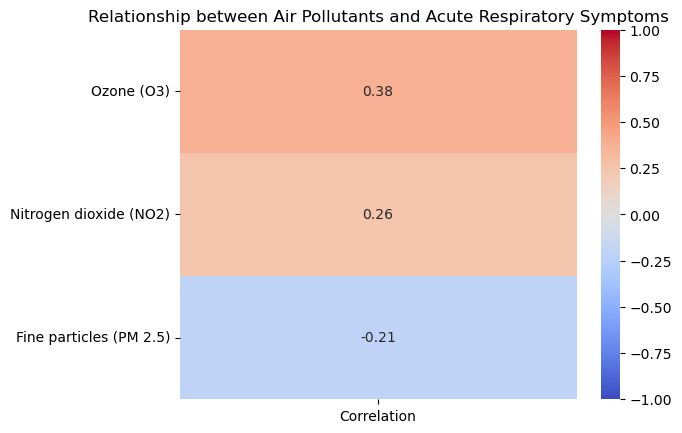

In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

aq_clean_path=os.path.join('data', 'processed', 'air_quality_clean.csv')
df_air=pd.read_csv(os.path.abspath(aq_clean_path))

ben_clean_path=os.path.join('data', 'processed', 'NYNY_BenMAP_clean.csv')
df_ben=pd.read_csv(os.path.abspath(ben_clean_path))

df_air_borough=df_air[df_air['Geo Type Name']=='Borough']

df_air_borough_a=df_air_borough[(df_air_borough['Name']=='Nitrogen dioxide (NO2)')|(df_air_borough['Name']=='Ozone (O3)')|(df_air_borough['Name']=='Fine particles (PM 2.5)')]

df_air_borough_b=df_air_borough_a[['Indicator ID', 'Name', 'Measure Info', 'Geo Place Name', 'Data Value']]

df_air_borough_b_group=df_air_borough_b.groupby(['Indicator ID', 'Name', 'Measure Info', 'Geo Place Name']).mean().sort_values('Geo Place Name').reset_index()

df_ben_a=df_ben[['bgrp', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']]

def get_borough_from_bgrp(bgrp):
    if 360050000000 <= bgrp <= 360059999999:
        return 'Bronx'
    elif 360470000000 <= bgrp <= 360479999999:
        return 'Brooklyn'
    elif 360610000000 <= bgrp <= 360619999999:
        return 'Manhattan'
    elif 360810000000 <= bgrp <= 360819999999:
        return 'Queens'
    elif 360850000000 <= bgrp <= 360859999999:
        return 'Staten Island'

df_ben_b=df_ben_a.copy()
df_ben_b['Borough'] = df_ben_b['bgrp'].apply(get_borough_from_bgrp)

ben_new_order=['bgrp', 'Borough', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']
df_ben_b=df_ben_b[ben_new_order]

no_brgp=['Borough', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']
df_ben_b_group=df_ben_b[no_brgp].groupby('Borough').sum().reset_index()

df_ben_melted = pd.melt(df_ben_b_group, id_vars=['Borough'],
                        value_vars=['NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I'],
                        var_name='Symptom Type', value_name='Symptom Value')
df_ben_melted = df_ben_melted.rename(columns={'Borough': 'Geo Place Name'})

symptom_name_mapping = {
    'NO2_Acute_Respiratory_Symptoms_I': 'Nitrogen dioxide (NO2)',
    'O3_Acute_Respiratory_Symptoms_I': 'Ozone (O3)',
    'PM25_Acute_Respiratory_Symptoms_I': 'Fine particles (PM 2.5)'
}
df_ben_melted['Name'] = df_ben_melted['Symptom Type'].map(symptom_name_mapping)

df_merged = pd.merge(df_air_borough_b_group, df_ben_melted, on=['Geo Place Name', 'Name'], how='inner')
df_merged=df_merged[['Geo Place Name', 'Indicator ID', 'Name', 'Measure Info', 'Data Value', 'Symptom Type', 'Symptom Value']].sort_values(['Geo Place Name', 'Symptom Type']). reset_index(drop=True)
df_merged=df_merged.rename(columns={'Data Value': 'Mean Measure Value'})
df_merged.to_csv(os.path.abspath('data/processed/merged.csv'), index=False)

df_merged_no2=df_merged[df_merged['Name']=='Nitrogen dioxide (NO2)']
df_merged_o3=df_merged[df_merged['Name']=='Ozone (O3)']
df_merged_pm=df_merged[df_merged['Name']=='Fine particles (PM 2.5)']

no2_corr=df_merged_no2['Mean Measure Value'].corr(df_merged_no2['Symptom Value'])
o3_corr=df_merged_o3['Mean Measure Value'].corr(df_merged_o3['Symptom Value'])
pm_corr=df_merged_pm['Mean Measure Value'].corr(df_merged_pm['Symptom Value'])

correlations_df = pd.DataFrame({
    'Correlation': [o3_corr, no2_corr, pm_corr]
}, index=['Ozone (O3)', 'Nitrogen dioxide (NO2)', 'Fine particles (PM 2.5)'])

sns.heatmap(correlations_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Relationship between Air Pollutants and Acute Respiratory Symptoms')
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()